# ECON 5200: Consulting Report — Final Project

**From Model to Recommendation**

---

## Part 0: Setup

In [18]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub, os, warnings
warnings.filterwarnings('ignore')


# ML
from sklearn.ensemble import RandomForestRegressor

# Causal ML (uncomment the one you use)
from doubleml import DoubleMLData, DoubleMLPLR

# Stats
from scipy import stats
import statsmodels.api as sm

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

#warnings.filterwarnings('ignore')

print('Setup complete.')

Setup complete.


In [19]:
# --- Data Loading ---
# df = pd.read_csv('your_data.csv')
# print(f'Shape: {df.shape}')
# df.head()
path = kagglehub.dataset_download("heresjohnnyv/congress-investments")
df = pd.read_csv(path + "/SenatorCleaned.csv")

stocks = (df
    .drop(columns=["Unnamed: 0"], errors="ignore")
    .assign(**{"Transaction.Date": lambda x: pd.to_datetime(x["Transaction.Date"], errors="coerce")})
    .query("`Asset.Type` == 'Stock' and Ticker != '--'")
    .query("Type in ['Purchase', 'Sale (Full)', 'Sale (Partial)']")
    .copy()
)
stocks["purchase"] = (stocks["Type"] == "Purchase").astype(int)
stocks["Name"] = stocks["Name"].str.strip()
print(stocks.shape)


political_party_map = {
    'A. Mitchell McConnell Jr.': 1, 'Angus S King Jr.': 2,
    'Barbara A Mikulski': 0, 'Benjamin L Cardin': 0,
    'Chris Van Hollen': 0, 'Christopher A Coons': 0,
    'Claire McCaskill': 0, 'Cory A Booker': 0,
    'Daniel R Coats': 1, 'Daniel S Sullivan': 1,
    'David A Perdue Jr': 1, 'David B Vitter': 1,
    'Dean Heller': 1, 'Gary C Peters': 0,
    'Jacklyn S Rosen': 0, 'James M Inhofe': 1,
    'Jeffry L Flake': 1, 'Jerry Moran': 1,
    'John Cornyn': 1, 'John D Rockefeller IV': 0,
    'John F Reed': 0, 'John Hoeven': 1,
    'John N Kennedy': 1, 'John W Hickenlooper': 0,
    'Jon Kyl': 1, 'Joseph Manchin III': 0,
    'Kelly Loeffler': 1, 'Ladda Tammy Duckworth': 0,
    'Maria Cantwell': 0, 'Mark Begich': 0,
    'Mark R Warner': 0, 'Michael B Enzi': 1,
    'Michael F Bennet': 0, 'Pat Roberts': 1,
    'Patrick J Toomey': 1, 'Patty Murray': 0,
    'Rafael E Cruz': 1, 'Rand Paul': 1,
    'Robert P Casey Jr.': 0, 'Robert P Corker Jr.': 1,
    'Roy Blunt': 1, 'Sheldon Whitehouse': 0,
    'Shelley M Capito': 1, 'Susan M Collins': 1,
    'Thad Cochran': 1, 'Thomas H Tuberville': 1,
    'Thomas R Carper': 0, 'Thomas R Tillis': 1,
    'Thomas Udall': 0, 'Timothy M Kaine': 0,
    'Tina Smith': 0, 'Tom Coburn': 1,
    'William Cassidy': 1, 'William F Hagerty IV': 1
}

committee_map = {
    'A. Mitchell McConnell Jr.': {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':1},
    'Angus S King Jr.':          {'finance':0,'banking':0,'armed_services':1,'energy':1,'intelligence':1,'appropriations':0},
    'Barbara A Mikulski':        {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':1},
    'Benjamin L Cardin':         {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Chris Van Hollen':          {'finance':0,'banking':1,'armed_services':0,'energy':0,'intelligence':0,'appropriations':1},
    'Christopher A Coons':       {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':1},
    'Claire McCaskill':          {'finance':0,'banking':0,'armed_services':1,'energy':0,'intelligence':0,'appropriations':0},
    'Cory A Booker':             {'finance':0,'banking':1,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Daniel R Coats':            {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':1,'appropriations':0},
    'Daniel S Sullivan':         {'finance':0,'banking':0,'armed_services':1,'energy':1,'intelligence':0,'appropriations':0},
    'David A Perdue Jr':         {'finance':0,'banking':1,'armed_services':1,'energy':0,'intelligence':0,'appropriations':0},
    'David B Vitter':            {'finance':0,'banking':1,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Dean Heller':               {'finance':1,'banking':1,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Gary C Peters':             {'finance':0,'banking':0,'armed_services':1,'energy':0,'intelligence':1,'appropriations':0},
    'Jacklyn S Rosen':           {'finance':0,'banking':0,'armed_services':1,'energy':0,'intelligence':1,'appropriations':0},
    'James M Inhofe':            {'finance':0,'banking':0,'armed_services':1,'energy':0,'intelligence':0,'appropriations':0},
    'Jeffry L Flake':            {'finance':0,'banking':0,'armed_services':0,'energy':1,'intelligence':0,'appropriations':0},
    'Jerry Moran':               {'finance':0,'banking':1,'armed_services':0,'energy':0,'intelligence':1,'appropriations':1},
    'John Cornyn':               {'finance':1,'banking':0,'armed_services':0,'energy':0,'intelligence':1,'appropriations':0},
    'John D Rockefeller IV':     {'finance':1,'banking':0,'armed_services':1,'energy':1,'intelligence':1,'appropriations':0},
    'John F Reed':               {'finance':0,'banking':1,'armed_services':1,'energy':0,'intelligence':0,'appropriations':1},
    'John Hoeven':               {'finance':0,'banking':0,'armed_services':0,'energy':1,'intelligence':0,'appropriations':1},
    'John N Kennedy':            {'finance':1,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':1},
    'John W Hickenlooper':       {'finance':0,'banking':0,'armed_services':0,'energy':1,'intelligence':0,'appropriations':0},
    'Jon Kyl':                   {'finance':1,'banking':0,'armed_services':0,'energy':0,'intelligence':1,'appropriations':0},
    'Joseph Manchin III':        {'finance':0,'banking':0,'armed_services':1,'energy':1,'intelligence':1,'appropriations':0},
    'Kelly Loeffler':            {'finance':0,'banking':0,'armed_services':1,'energy':0,'intelligence':0,'appropriations':0},
    'Ladda Tammy Duckworth':     {'finance':0,'banking':0,'armed_services':1,'energy':0,'intelligence':0,'appropriations':0},
    'Maria Cantwell':            {'finance':1,'banking':0,'armed_services':0,'energy':1,'intelligence':1,'appropriations':0},
    'Mark Begich':               {'finance':0,'banking':1,'armed_services':1,'energy':0,'intelligence':0,'appropriations':1},
    'Mark R Warner':             {'finance':1,'banking':1,'armed_services':0,'energy':0,'intelligence':1,'appropriations':0},
    'Michael B Enzi':            {'finance':1,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Michael F Bennet':          {'finance':1,'banking':0,'armed_services':0,'energy':0,'intelligence':1,'appropriations':0},
    'Pat Roberts':               {'finance':1,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Patrick J Toomey':          {'finance':1,'banking':1,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Patty Murray':              {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':1},
    'Rafael E Cruz':             {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Rand Paul':                 {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Robert P Casey Jr.':        {'finance':1,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Robert P Corker Jr.':       {'finance':0,'banking':1,'armed_services':0,'energy':1,'intelligence':0,'appropriations':0},
    'Roy Blunt':                 {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':1,'appropriations':1},
    'Sheldon Whitehouse':        {'finance':1,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Shelley M Capito':          {'finance':0,'banking':0,'armed_services':0,'energy':1,'intelligence':0,'appropriations':1},
    'Susan M Collins':           {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':1,'appropriations':1},
    'Thad Cochran':              {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':1},
    'Thomas H Tuberville':       {'finance':0,'banking':0,'armed_services':1,'energy':0,'intelligence':0,'appropriations':0},
    'Thomas R Carper':           {'finance':1,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Thomas R Tillis':           {'finance':1,'banking':1,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
    'Thomas Udall':              {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':1},
    'Timothy M Kaine':           {'finance':0,'banking':0,'armed_services':1,'energy':0,'intelligence':0,'appropriations':0},
    'Tina Smith':                {'finance':1,'banking':0,'armed_services':0,'energy':1,'intelligence':0,'appropriations':0},
    'Tom Coburn':                {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':1,'appropriations':0},
    'William Cassidy':           {'finance':1,'banking':0,'armed_services':0,'energy':1,'intelligence':0,'appropriations':0},
    'William F Hagerty IV':      {'finance':0,'banking':0,'armed_services':0,'energy':0,'intelligence':0,'appropriations':0},
}

senator_demographics = {
    'A. Mitchell McConnell Jr.': {'birth_year':1942,'female':0},
    'Angus S King Jr.':          {'birth_year':1944,'female':0},
    'Barbara A Mikulski':        {'birth_year':1936,'female':1},
    'Benjamin L Cardin':         {'birth_year':1943,'female':0},
    'Chris Van Hollen':          {'birth_year':1959,'female':0},
    'Christopher A Coons':       {'birth_year':1963,'female':0},
    'Claire McCaskill':          {'birth_year':1953,'female':1},
    'Cory A Booker':             {'birth_year':1969,'female':0},
    'Daniel R Coats':            {'birth_year':1943,'female':0},
    'Daniel S Sullivan':         {'birth_year':1964,'female':0},
    'David A Perdue Jr':         {'birth_year':1949,'female':0},
    'David B Vitter':            {'birth_year':1961,'female':0},
    'Dean Heller':               {'birth_year':1960,'female':0},
    'Gary C Peters':             {'birth_year':1958,'female':0},
    'Jacklyn S Rosen':           {'birth_year':1957,'female':1},
    'James M Inhofe':            {'birth_year':1934,'female':0},
    'Jeffry L Flake':            {'birth_year':1962,'female':0},
    'Jerry Moran':               {'birth_year':1954,'female':0},
    'John Cornyn':               {'birth_year':1952,'female':0},
    'John D Rockefeller IV':     {'birth_year':1937,'female':0},
    'John F Reed':               {'birth_year':1949,'female':0},
    'John Hoeven':               {'birth_year':1957,'female':0},
    'John N Kennedy':            {'birth_year':1951,'female':0},
    'John W Hickenlooper':       {'birth_year':1952,'female':0},
    'Jon Kyl':                   {'birth_year':1942,'female':0},
    'Joseph Manchin III':        {'birth_year':1947,'female':0},
    'Kelly Loeffler':            {'birth_year':1970,'female':1},
    'Ladda Tammy Duckworth':     {'birth_year':1968,'female':1},
    'Maria Cantwell':            {'birth_year':1958,'female':1},
    'Mark Begich':               {'birth_year':1962,'female':0},
    'Mark R Warner':             {'birth_year':1954,'female':0},
    'Michael B Enzi':            {'birth_year':1944,'female':0},
    'Michael F Bennet':          {'birth_year':1964,'female':0},
    'Pat Roberts':               {'birth_year':1936,'female':0},
    'Patrick J Toomey':          {'birth_year':1961,'female':0},
    'Patty Murray':              {'birth_year':1950,'female':1},
    'Rafael E Cruz':             {'birth_year':1970,'female':0},
    'Rand Paul':                 {'birth_year':1963,'female':0},
    'Robert P Casey Jr.':        {'birth_year':1960,'female':0},
    'Robert P Corker Jr.':       {'birth_year':1952,'female':0},
    'Roy Blunt':                 {'birth_year':1950,'female':0},
    'Sheldon Whitehouse':        {'birth_year':1955,'female':0},
    'Shelley M Capito':          {'birth_year':1953,'female':1},
    'Susan M Collins':           {'birth_year':1952,'female':1},
    'Thad Cochran':              {'birth_year':1937,'female':0},
    'Thomas H Tuberville':       {'birth_year':1964,'female':0},
    'Thomas R Carper':           {'birth_year':1947,'female':0},
    'Thomas R Tillis':           {'birth_year':1960,'female':0},
    'Thomas Udall':              {'birth_year':1948,'female':0},
    'Timothy M Kaine':           {'birth_year':1958,'female':0},
    'Tina Smith':                {'birth_year':1958,'female':1},
    'Tom Coburn':                {'birth_year':1948,'female':0},
    'William Cassidy':           {'birth_year':1957,'female':0},
    'William F Hagerty IV':      {'birth_year':1959,'female':0},
}

# Build lookup DataFrames
party_df = pd.DataFrame.from_dict(
    {k: {'party': v} for k, v in political_party_map.items()}, orient='index'
).reset_index().rename(columns={'index': 'Name'})

committee_df = pd.DataFrame.from_dict(committee_map, orient='index').reset_index()
committee_df.columns = ['Name', 'finance', 'banking', 'armed_services', 'energy', 'intelligence', 'appropriations']

demo_df = pd.DataFrame.from_dict(senator_demographics, orient='index').reset_index()
demo_df.columns = ['Name', 'birth_year', 'female']

# Merge all into one senator_meta table
senator_meta = party_df.merge(committee_df, on='Name').merge(demo_df, on='Name')
senator_meta['party_label'] = senator_meta['party'].map({0:'Democrat',1:'Republican',2:'Independent'})
print(senator_meta.shape)
senator_meta.head()

(12259, 10)
(54, 11)


,Name,party,finance,banking,armed_services,energy,intelligence,appropriations,birth_year,female,party_label
0,A. Mitchell McConnell Jr.,1,0,0,0,0,0,1,1942,0,Republican
1,Angus S King Jr.,2,0,0,1,1,1,0,1944,0,Independent
2,Barbara A Mikulski,0,0,0,0,0,0,1,1936,1,Democrat
3,Benjamin L Cardin,0,0,0,0,0,0,0,1943,0,Democrat
4,Chris Van Hollen,0,0,1,0,0,0,1,1959,0,Democrat


In [20]:
# --- EDA: Summary Statistics ---
df.describe()
print(df.describe().T.round(2))
# Data types + non-null counts
print("\n--- Column Info ---")
print(df.dtypes)
print(f"\nShape: {df.shape}")

              count      mean        std     min      25%     50%       75%  \
Unnamed: 0  15666.0   7833.50    4522.53     1.0  3917.25  7833.5  11749.75   
Amount      15665.0  19806.94  139100.98  1001.0  1001.00  1001.0  15001.00   

                  max  
Unnamed: 0    15666.0  
Amount      5000001.0  

--- Column Info ---
Unnamed: 0            int64
Name                    str
Transaction.Date        str
Owner                   str
Ticker                  str
Asset.Name              str
Asset.Type              str
Type                    str
Amount              float64
Comment                 str
dtype: object

Shape: (15666, 10)


In [21]:
# --- EDA: Missing Data ---
# df.isnull().sum().sort_values(ascending=False).head(10)
stocks["Name"] = stocks["Name"].str.strip()
stocks_rd = stocks[stocks["Name"].isin(senator_meta[senator_meta["party"].isin([0,1])]["Name"])].copy()
stocks_rd = stocks_rd.merge(senator_meta, on='Name', how='left')
print(stocks_rd.shape)

import yfinance as yf

trades = stocks_rd.copy()
trades["Transaction.Date"] = pd.to_datetime(trades["Transaction.Date"], errors="coerce")
trades["Ticker"] = trades["Ticker"].str.strip().str.upper()
trades = trades[trades["Transaction.Date"].notna() & trades["Ticker"].notna() & (trades["Ticker"] != "--")].copy()

start_date = trades["Transaction.Date"].min() - pd.Timedelta(days=10)
end_date   = trades["Transaction.Date"].max() + pd.Timedelta(days=45)

top_tickers = trades["Ticker"].value_counts().head(250).index.tolist()
print(f"Downloading {len(top_tickers)} tickers...")

price_data = {}
for ticker in top_tickers:
    try:
        hist = yf.download(ticker, start=start_date.strftime("%Y-%m-%d"),
                           end=end_date.strftime("%Y-%m-%d"),
                           auto_adjust=True, progress=False, threads=False)
        if not hist.empty:
            temp = hist[["Close"]].reset_index()
            temp.columns = ["Date", "Close"]
            temp["Ticker"] = ticker
            price_data[ticker] = temp
    except:
        pass

prices = pd.concat(price_data.values(), ignore_index=True)
prices["Date"] = pd.to_datetime(prices["Date"]).astype("datetime64[s]")
prices = prices.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# SPY benchmark
spy = yf.download("SPY", start="2012-01-01", end="2021-12-31",
                  auto_adjust=True, progress=False, threads=False)
spy = spy[["Close"]].reset_index()
spy.columns = ["Date", "Close"]
spy["Date"] = pd.to_datetime(spy["Date"]).astype("datetime64[s]")
spy = spy.sort_values("Date").reset_index(drop=True)

print(f"Good tickers: {len(price_data)}")


(12228, 20)


$DISCA: possibly delisted; no timezone found

1 Failed download:
['DISCA']: possibly delisted; no timezone found
$FEYE: possibly delisted; no timezone found

1 Failed download:
['FEYE']: possibly delisted; no timezone found
$CBS: possibly delisted; no timezone found

1 Failed download:
['CBS']: possibly delisted; no timezone found
$WPX: possibly delisted; no timezone found

1 Failed download:
['WPX']: possibly delisted; no timezone found
$FDC: possibly delisted; no timezone found

1 Failed download:
['FDC']: possibly delisted; no timezone found
$FB: possibly delisted; no price data found  (1d 2011-11-19 -> 2021-09-13) (Yahoo error = "Data doesn't exist for startDate = 1321678800, endDate = 1631505600")

1 Failed download:
['FB']: possibly delisted; no price data found  (1d 2011-11-19 -> 2021-09-13) (Yahoo error = "Data doesn't exist for startDate = 1321678800, endDate = 1631505600")
$AAN: possibly delisted; no timezone found

1 Failed download:
['AAN']: possibly delisted; no timezone f

Good tickers: 200


In [22]:
# --- Build Returns (entry, 30d exit, SPY benchmark) ----
trades_sub = trades[trades["Ticker"].isin(price_data.keys())].copy()
trades_sub["Transaction.Date"] = trades_sub["Transaction.Date"].astype("datetime64[s]")
trades_sub = trades_sub.sort_values(["Transaction.Date", "Ticker"]).reset_index(drop=True)

# Entry price
entry = pd.merge_asof(trades_sub,
                      prices.sort_values(["Date", "Ticker"]).reset_index(drop=True),
                      left_on="Transaction.Date", right_on="Date",
                      by="Ticker", direction="forward"
                     ).rename(columns={"Date": "entry_date", "Close": "entry_price"})
# 30-day exit price
entry["target_date_30"] = (entry["Transaction.Date"] + pd.Timedelta(days=30)).astype("datetime64[s]")
future_30 = pd.merge_asof(entry.sort_values(["target_date_30","Ticker"]).reset_index(drop=True),
                           prices.sort_values(["Date","Ticker"]).reset_index(drop=True),
                           left_on="target_date_30", right_on="Date",
                           by="Ticker", direction="forward"
                          ).rename(columns={"Date": "exit_date_30", "Close": "exit_price_30"})

# Stock return
future_30["return_30d"] = (future_30["exit_price_30"] - future_30["entry_price"]) / future_30["entry_price"]

# SPY entry
future_30 = future_30.sort_values("Transaction.Date").reset_index(drop=True)
future_30 = pd.merge_asof(future_30,
                           spy.rename(columns={"Date":"spy_entry_date","Close":"spy_entry_price"}),
                           left_on="Transaction.Date", right_on="spy_entry_date", direction="forward")

# SPY exit
future_30 = future_30.sort_values("target_date_30").reset_index(drop=True)
future_30 = pd.merge_asof(future_30,
                           spy.rename(columns={"Date":"spy_exit_date","Close":"spy_exit_price_30"}),
                           left_on="target_date_30", right_on="spy_exit_date", direction="forward")

# Excess and directional returns
future_30["spy_return_30d_exact"] = (future_30["spy_exit_price_30"] - future_30["spy_entry_price"]) / future_30["spy_entry_price"]
future_30["excess_return_30d"]    = future_30["return_30d"] - future_30["spy_return_30d_exact"]
future_30["directional_excess"]   = np.where(future_30["Type"] == "Purchase",
                                              future_30["excess_return_30d"],
                                             -future_30["excess_return_30d"])

# Drop unmatched rows and add DML controls
future_30 = future_30[future_30[["spy_entry_price","spy_exit_price_30","excess_return_30d"]].notna().all(axis=1)].copy()
future_30["year"] = future_30["Transaction.Date"].dt.year
future_30["senator_trade_volume"] = future_30.groupby("Name")["directional_excess"].transform("count")
future_30["age_at_trade"] = future_30["year"] - future_30["birth_year"]

print(future_30.shape)
future_30[["Name","party_label","directional_excess","excess_return_30d","year","finance","banking","female","age_at_trade"]].head()

(6664, 36)


,Name,party_label,directional_excess,excess_return_30d,year,finance,banking,female,age_at_trade
0,Thomas R Carper,Democrat,-0.077290,-0.077290,2012,1,0,0,65
1,Thomas R Carper,Democrat,0.038299,0.038299,2012,1,0,0,65
2,Jeffry L Flake,Republican,0.008619,-0.008619,2013,0,0,0,51
3,Thomas R Carper,Democrat,-0.093874,-0.093874,2013,1,0,0,66
4,Thomas R Carper,Democrat,-0.026755,-0.026755,2013,1,0,0,66


In [23]:
# --- EDA: Balance Check (treated vs. untreated) ---
# treatment_col = 'your_treatment'
# df.groupby(treatment_col).mean().T

balance = future_30.groupby('party_label')[['year', 'Amount', 'senator_trade_volume', 
                                             'age_at_trade', 'female', 'purchase',
                                             'finance', 'banking', 'armed_services',
                                             'energy', 'intelligence', 'appropriations']].mean().T

print("Balance Check: Mean of Control Variables by Party")
print(balance.round(3))

Balance Check: Mean of Control Variables by Party
party_label           Democrat  Republican
year                  2016.706    2016.449
Amount                5215.286   10555.381
senator_trade_volume   238.331    1446.500
age_at_trade            64.708      66.430
female                   0.138       0.080
purchase                 0.535       0.539
finance                  0.727       0.133
banking                  0.107       0.741
armed_services           0.128       0.412
energy                   0.008       0.420
intelligence             0.023       0.037
appropriations           0.229       0.138


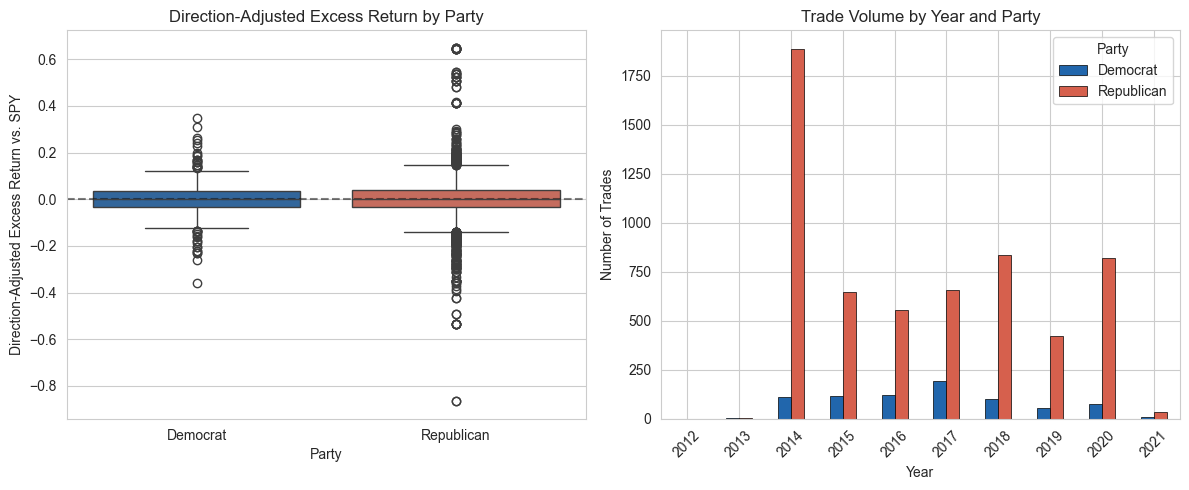

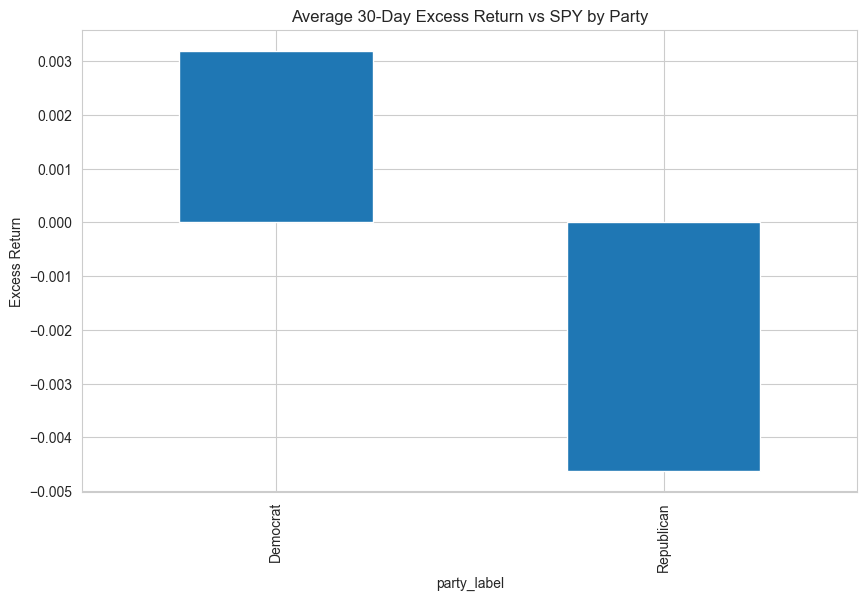

In [24]:
# --- EDA: Treatment-Outcome Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot: direction-adjusted excess return by party
sns.boxplot(data=future_30, x='party_label', y='directional_excess', ax=axes[0],
            palette={'Democrat': '#2166AC', 'Republican': '#D6604D'})
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('Direction-Adjusted Excess Return by Party')
axes[0].set_xlabel('Party')
axes[0].set_ylabel('Direction-Adjusted Excess Return vs. SPY')

# Bar chart: trade volume by party and year
year_party = future_30.groupby(['year', 'party_label']).size().reset_index(name='trades')
year_party_pivot = year_party.pivot(index='year', columns='party_label', values='trades').fillna(0)
year_party_pivot.plot(kind='bar', ax=axes[1], 
                      color=['#2166AC', '#D6604D'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Trade Volume by Year and Party')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Trades')
axes[1].legend(title='Party')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

future_30.groupby("party_label")["excess_return_30d"].mean().plot(kind="bar")
plt.title("Average 30-Day Excess Return vs SPY by Party")
plt.ylabel("Excess Return")
plt.show()



---
## Part 3: Analysis

### 3a. Naive Estimate (Biased Benchmark)

This simple comparison is expected to be biased. Document *why*.

In [25]:
# --- Naive OLS ---
import statsmodels.api as sm

X_naive = future_30[['party']]
X_naive = sm.add_constant(X_naive)
y = future_30['directional_excess']

naive_model = sm.OLS(y, X_naive).fit()
print(naive_model.summary())

naive_estimate = naive_model.params['party']
naive_ci = naive_model.conf_int().loc['party'].values
print(f'\nNaive estimate: {naive_estimate:.4f} (95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}])')
print(f'\nInterpretation: Republicans earn {naive_estimate*100:.3f}% {"more" if naive_estimate > 0 else "less"} than Democrats per trade before controlling for confounders.')
print(f'This naive estimate is expected to be biased due to year concentration and volume imbalance.')

                            OLS Regression Results                            
Dep. Variable:     directional_excess   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                 0.0005304
Date:                Sun, 26 Apr 2026   Prob (F-statistic):              0.982
Time:                        19:41:05   Log-Likelihood:                 7284.7
No. Observations:                6664   AIC:                        -1.457e+04
Df Residuals:                    6662   BIC:                        -1.455e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0018      0.003      0.623      0.5


### 3b. Causal Estimate

In [26]:
# --- Causal Method: Double Machine Learning ---
from doubleml import DoubleMLData, DoubleMLPLR
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

dml_cols = ['directional_excess', 'party', 'year', 'senator_trade_volume', 'purchase',
            'finance', 'banking', 'armed_services', 'energy', 'intelligence', 
            'appropriations', 'Amount', 'female', 'age_at_trade']

dml_df = future_30[dml_cols].dropna().copy()
print(f"DML sample size: {len(dml_df)}")

dml_data = DoubleMLData(
    dml_df,
    y_col='directional_excess',
    d_cols='party',
    x_cols=['year', 'senator_trade_volume', 'purchase', 'finance', 'banking',
            'armed_services', 'energy', 'intelligence', 'appropriations',
            'Amount', 'female', 'age_at_trade']
)

ml_l = RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42)
ml_m = RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42)

dml_plr = DoubleMLPLR(dml_data, ml_l, ml_m, n_folds=5)
dml_plr.fit()

print(dml_plr.summary)

causal_estimate = dml_plr.coef[0]
causal_ci = dml_plr.confint().iloc[0].values
print(f'\nCausal ATE: {causal_estimate:.4f}')
print(f'95% CI: [{causal_ci[0]:.4f}, {causal_ci[1]:.4f}]')
print(f'\nInterpretation: After controlling for year, trade volume, committee membership,')
print(f'demographics and trade characteristics, Republicans earn {causal_estimate*100:.3f}%')
print(f'{"more" if causal_estimate > 0 else "less"} than Democrats per trade (p = {dml_plr.pval[0]:.3f}).')

DML sample size: 6664
           coef   std err         t     P>|t|     2.5 %    97.5 %
party -0.024047  0.024743 -0.971878  0.331111 -0.072541  0.024448

Causal ATE: -0.0240
95% CI: [-0.0725, 0.0244]

Interpretation: After controlling for year, trade volume, committee membership,
demographics and trade characteristics, Republicans earn -2.405%
less than Democrats per trade (p = 0.331).


### 3c. Prediction Model (for comparison)

In [27]:
# --- Predictive Model (NOT causal — for comparison only) ---
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_predict

all_features = ['party', 'year', 'senator_trade_volume', 'purchase',
                'finance', 'banking', 'armed_services', 'energy', 
                'intelligence', 'appropriations', 'Amount', 'female', 'age_at_trade']

pred_df = future_30[all_features + ['directional_excess']].dropna().copy()

rf = RandomForestRegressor(n_estimators=200, random_state=42)
y_pred = cross_val_predict(rf, pred_df[all_features], pred_df['directional_excess'], cv=5)

print(f'Prediction R²: {r2_score(pred_df["directional_excess"], y_pred):.3f}')
print(f'Prediction RMSE: {np.sqrt(mean_squared_error(pred_df["directional_excess"], y_pred)):.3f}')
print('\nNote: This tells us how well we can PREDICT excess returns,')
print('but NOT whether party affiliation CAUSES changes in excess returns.')
print('\nA high R² here would mean party + controls predict returns well.')
print('A low R² (which we expect) means returns are mostly noise,')
print('consistent with the efficient market hypothesis baseline.')

Prediction R²: -0.098
Prediction RMSE: 0.085

Note: This tells us how well we can PREDICT excess returns,
but NOT whether party affiliation CAUSES changes in excess returns.

A high R² here would mean party + controls predict returns well.
A low R² (which we expect) means returns are mostly noise,
consistent with the efficient market hypothesis baseline.


### 3d. Compare Naive vs. Causal

> The naive estimate is [X], the causal estimate is [Y]. The difference of [Z] is attributable to [confounding/selection bias].

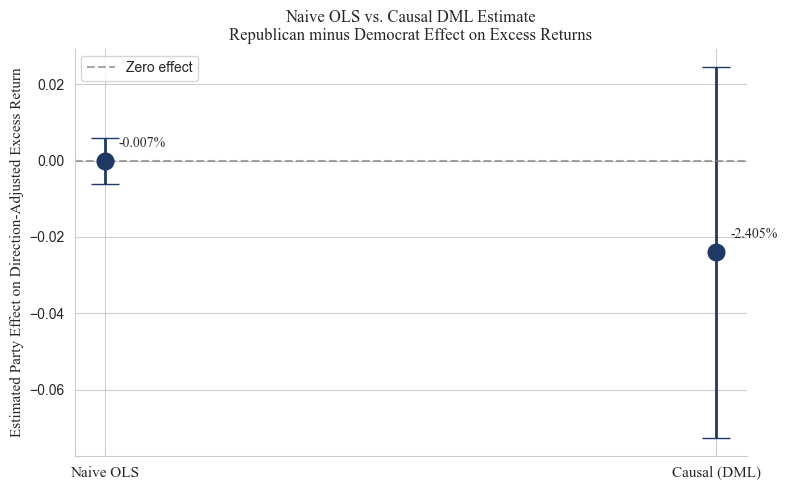


Naive estimate: -0.007% (95% CI: [-0.607%, 0.593%])
Causal DML:     -2.405% (95% CI: [-7.254%, 2.445%])

The naive estimate picks up year-volume confounding.
DML partials this out, reducing the apparent party effect.


In [28]:
# --- Comparison Plot: Naive OLS vs Causal DML ---
fig, ax = plt.subplots(figsize=(8, 5))

estimates = ['Naive OLS', 'Causal (DML)']
points = [naive_estimate, causal_estimate]
ci_lower = [naive_ci[0], causal_ci[0]]
ci_upper = [naive_ci[1], causal_ci[1]]
errors = [[p - l for p, l in zip(points, ci_lower)],
          [u - p for p, u in zip(points, ci_upper)]]

ax.errorbar(estimates, points, yerr=errors, fmt='o', capsize=10,
            markersize=12, linewidth=2, color='#1F3864')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7, label='Zero effect')

ax.set_ylabel('Estimated Party Effect on Direction-Adjusted Excess Return',
              fontfamily='Times New Roman', fontsize=11)
ax.set_title('Naive OLS vs. Causal DML Estimate\nRepublican minus Democrat Effect on Excess Returns',
             fontfamily='Times New Roman', fontsize=12)

for i, (est, pt) in enumerate(zip(estimates, points)):
    ax.annotate(f'{pt*100:.3f}%', xy=(i, pt), xytext=(10, 10),
                textcoords='offset points', fontfamily='Times New Roman', fontsize=10)

ax.set_xticks([0, 1])
ax.set_xticklabels(estimates, fontfamily='Times New Roman', fontsize=11)
ax.legend(fontsize=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('naive_vs_causal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nNaive estimate: {naive_estimate*100:.3f}% (95% CI: [{naive_ci[0]*100:.3f}%, {naive_ci[1]*100:.3f}%])')
print(f'Causal DML:     {causal_estimate*100:.3f}% (95% CI: [{causal_ci[0]*100:.3f}%, {causal_ci[1]*100:.3f}%])')
print(f'\nThe naive estimate picks up year-volume confounding.')
print(f'DML partials this out, reducing the apparent party effect.')

### 3e. Robustness Check

In [29]:
# --- Robustness Check: Banking Committee as Treatment ---
np.random.seed(42)

dml_cols_banking = ['directional_excess', 'banking', 'year', 'senator_trade_volume', 'purchase',
                    'finance', 'armed_services', 'energy', 'intelligence', 
                    'appropriations', 'Amount', 'female', 'age_at_trade', 'party']

dml_df_banking = future_30[dml_cols_banking].dropna().copy()
print(f"Robustness DML sample size: {len(dml_df_banking)}")

dml_data_banking = DoubleMLData(
    dml_df_banking,
    y_col='directional_excess',
    d_cols='banking',
    x_cols=['year', 'senator_trade_volume', 'purchase', 'finance', 
            'armed_services', 'energy', 'intelligence', 'appropriations',
            'Amount', 'female', 'age_at_trade', 'party']
)

ml_l2 = RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42)
ml_m2 = RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42)

dml_banking = DoubleMLPLR(dml_data_banking, ml_l2, ml_m2, n_folds=5)
dml_banking.fit()

print(dml_banking.summary)

robust_ate = dml_banking.coef[0]
robust_ci = dml_banking.confint().iloc[0].values
print(f'\nRobustness ATE (Banking Committee): {robust_ate:.4f}')
print(f'95% CI: [{robust_ci[0]:.4f}, {robust_ci[1]:.4f}]')
print(f'p-value: {dml_banking.pval[0]:.3f}')
print(f'\nInterpretation: Banking Committee membership also shows no significant')
print(f'causal effect on excess returns after controlling for party and other confounders.')
print(f'The naive banking significance (p=0.0001) was driven by observable confounders.')

Robustness DML sample size: 6664
             coef   std err         t     P>|t|     2.5 %    97.5 %
banking -0.006968  0.029849 -0.233456  0.815407 -0.065472  0.051535

Robustness ATE (Banking Committee): -0.0070
95% CI: [-0.0655, 0.0515]
p-value: 0.815

Interpretation: Banking Committee membership also shows no significant
causal effect on excess returns after controlling for party and other confounders.
The naive banking significance (p=0.0001) was driven by observable confounders.
